<a href="https://colab.research.google.com/github/mibucko/ml-product-categories/blob/main/product_categories_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook is part of a machine learning project in which we are developing a model to predict the product category based on the input data. The documents are available on GitHub at the following link:
https://github.com/mibucko/ml-product-categories

1. Raw data gathering

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/mibucko/ml-product-categories/main/products.csv"
df = pd.read_csv(url)

1.1. Column names standardization

In [ ]:
df.columns = (df.columns.str.strip().str.lower().str.replace(r"[\s_]+", "_", regex=True).str.strip("_"))
print(df.columns)

Index(['product_id', 'product_title', 'merchant_id', 'category_label',
       'product_code', 'number_of_views', 'merchant_rating', 'listing_date'],
      dtype='object')


1.2. Brief view on data

In [ ]:
print("Number of rows:", len(df))
print("Sample rows:")
print(df.sample(5))

Number of rows: 35311
Sample rows:
       product_id                                      product_title  \
32546       44352  liebherr ik2764 140cm integrated in column fri...   
23694       34402    bush wmnsint714w 7kg 1400 washing machine white   
27536       38720  liebherr cnef3915 comfort freestanding nofrost...   
26001       36979          beko fxs5043s undercounter freezer silver   
19035       29184  siemens geschirrsp ler speedmatic45 unterbauge...   

       merchant_id    category_label product_code  number_of_views  \
32546          301           Fridges   ET-7012-LP            521.0   
23694           22  Washing Machines   MQ-9227-JZ            912.0   
27536            3   Fridge Freezers   LW-2677-RX           2626.0   
26001            7          Freezers   JZ-1376-VM            295.0   
19035          298       Dishwashers   OV-5537-AB           2771.0   

       merchant_rating listing_date  
32546              3.8     3/1/2023  
23694              3.8    4/17/2022

1.3. We erase columns that definitely cannot influence product category: product_id, merchant_id, number_of_views, merchant_rating and listing_date.

In [ ]:
df = df.drop(columns=["product_id", "merchant_id", "number_of_views",
    "merchant_rating", "listing_date"])

2. Exploratory data analysis – EDA

2.1. What categories are present in dataset?

In [ ]:
print("Number of categories:", df["category_label"].nunique())
print(df["category_label"].value_counts())

Number of categories: 13
category_label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


2.2. Is the product code related to the product category?

We choose two categories as an example. By visual inspection, we can see that there is no apparent correlation between the product code and the product category. Therefore, we also drop this column from the dataset.

In [ ]:
mobile_phones = df[df["category_label"] == "Mobile Phones"]
cameras = df[df["category_label"] == "Digital Cameras"]
print('mobile phones')
print(mobile_phones[["product_code", "category_label"]].sample(20))
print('cameras')
print(cameras[["product_code", "category_label"]].sample(20))

mobile phones
     product_code category_label
3231   FT-9669-RF  Mobile Phones
957    DB-3859-WL  Mobile Phones
3124   IM-2705-UQ  Mobile Phones
79     HC-1210-NH  Mobile Phones
322    SC-3817-TD  Mobile Phones
2656   JT-3145-LF  Mobile Phones
3152   QJ-8930-BH  Mobile Phones
2171   ZY-6791-GI  Mobile Phones
1351   OZ-1608-WI  Mobile Phones
2847   VA-8594-EB  Mobile Phones
2013   EV-2044-CV  Mobile Phones
1464   KM-9263-DG  Mobile Phones
3636   DF-5742-DC  Mobile Phones
297    PF-5372-TV  Mobile Phones
1340   CU-1183-XB  Mobile Phones
2897   FN-0028-VU  Mobile Phones
1750   KM-9182-PY  Mobile Phones
373    LG-2021-AK  Mobile Phones
710    QZ-2160-DW  Mobile Phones
3468   PJ-0524-TD  Mobile Phones
cameras
      product_code   category_label
12768   JT-5806-FO  Digital Cameras
12901   NE-4196-QW  Digital Cameras
13120   GP-2492-IF  Digital Cameras
12546   KQ-8480-EH  Digital Cameras
13656   YZ-0606-CH  Digital Cameras
11907   VO-7147-UO  Digital Cameras
13225   ED-3268-DN  Digital Camer

In [ ]:
df = df.drop(columns=["product_code"])
print('Remaining columns:')
print(df.columns)

Remaining columns:
Index(['product_title', 'category_label'], dtype='object')


3. Data processing

3.1 Merging similar categories

In [ ]:
df["category_label"] = df["category_label"].replace({
    "Mobile Phone": "Mobile Phones",
    "CPU": "CPUs",
    "fridge": "Fridges"
})
print(df["category_label"].value_counts())

category_label
Fridge Freezers     5495
Mobile Phones       4075
Washing Machines    4036
CPUs                3855
Fridges             3580
TVs                 3564
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
Name: count, dtype: int64


3.2. Handling Missing Values

There are 171 rows without a product title, so we drop these rows. There are also 43 rows without a product category. We remove these rows from the original dataset and store them separately in a dataset called only_title, so that we can potentially use them later to test our model.

In [ ]:
df = df.dropna(subset=["product_title", "category_label"], how="all")
print("product_title:", df["product_title"].isna().sum())
print("category_label:", df["category_label"].isna().sum())
only_title = df[df["category_label"].isna()]
print(only_title.sample(5))

product_title: 171
category_label: 43
                                           product_title category_label
23046    electra free standing washing machine in silver            NaN
20223                          with ecobubble technology            NaN
12486       canon eos m5 mirrorless camera body in black            NaN
19166  siemens gro raum geschirrsp ler speedmatic sx6...            NaN
25623                     statesman chf150 chest freezer            NaN


4. Feature engineering

4.1 Brief look at product titles

In [ ]:
sample = df.sample(20).sort_values("category_label")
print(sample[["category_label", "product_title"]].to_string(index=False))

  category_label                                                                                  product_title
            CPUs                                           intel core i5 7640x processor 4 ghz 6 mb smart cache
            CPUs                    intel core i3 8300t 3.2 ghz 4 cores 4 threads 8 mb cache lga1151 socket oem
 Digital Cameras canon sx730hs si digital camera 20 mpix optical zoom 25 x silver wi fi bluetooth full hd video
     Dishwashers                                     gorenje gs62010suk 12 place freestanding dishwasher silver
     Dishwashers                                                    essentials cdwtt15 compact dishwasher white
     Dishwashers          bosch sps66tw00g serie 6 silence plus 10 place slimline freestanding dishwasher white
        Freezers                                                           hotpoint freezers 55cm 85cm a static
 Fridge Freezers                                   zanussi zrb35426wa a frost free 338l fridge freezer i

4.2

Title word count summary by category:
                   count       mean       std  min   25%   50%   75%   max
category_label                                                            
CPUs              3831.0  12.417123  3.805501  2.0  10.0  12.0  15.0  29.0
Digital Cameras   2689.0   9.626255  4.681738  2.0   6.0   9.0  12.0  36.0
Dishwashers       3405.0   6.812041  2.797289  2.0   5.0   7.0   8.0  29.0
Freezers          2201.0   7.208542  3.016416  1.0   5.0   7.0   9.0  24.0
Fridge Freezers   5470.0   8.187203  3.282636  1.0   6.0   8.0  10.0  24.0
Fridges           3559.0   7.486654  3.108996  1.0   5.0   7.0   9.0  28.0
Microwaves        2328.0   7.643900  3.160768  2.0   5.0   8.0  10.0  26.0
Mobile Phones     4057.0   8.552625  5.613782  2.0   5.0   7.0  11.0  37.0
TVs               3541.0  10.249365  4.473109  2.0   7.0  10.0  13.0  31.0
Washing Machines  4015.0   7.824658  3.127046  2.0   6.0   8.0  10.0  22.0


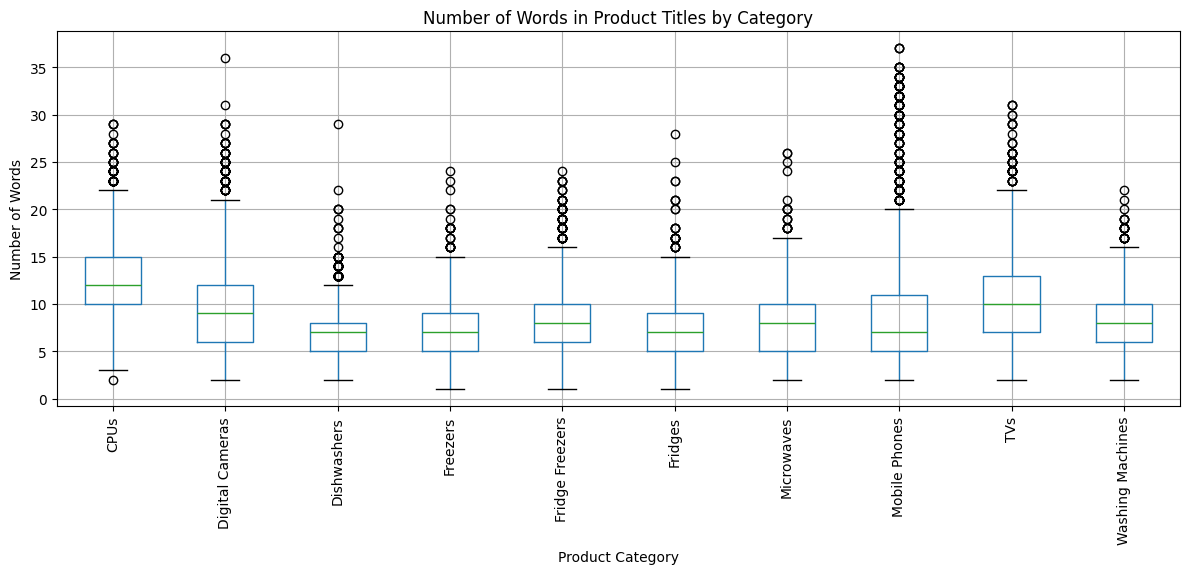

In [95]:
import matplotlib.pyplot as plt

# Number of words in the product title
df["title_word_count"] = df["product_title"].str.split().str.len()

# Show summary statistics grouped by product category
print("Title word count summary by category:")
print(df.groupby("category_label", observed=False)["title_word_count"].describe())

df.boxplot(
    column="title_word_count",
    by="category_label",
    figsize=(12, 6),
    rot=90
)

plt.title("Number of Words in Product Titles by Category")
plt.suptitle("")
plt.xlabel("Product Category")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()